In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 20

In [2]:
DP = DP()
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_dps_test.fits')
all_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_all_test.fits')
nbcs_df, _, _, _ = DP.extract_fits_data('./catalogs/0428_nbcs_test.fits')

In [3]:
dps_df.columns

Index(['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'DV_R', 'DV_L',
       'SIGMA_R', 'SIGMA_L', 'SIGMA_1COMP', 'P_VALUE', 'OII3726_FLUX_1COMP',
       'OII3729_FLUX_1COMP', 'Hbeta_FLUX_1COMP', 'OIII4959_FLUX_1COMP',
       'OIII5007_FLUX_1COMP', 'NII6548_FLUX_1COMP', 'Halpha_FLUX_1COMP',
       'NII6583_FLUX_1COMP', 'SII6716_FLUX_1COMP', 'SII6731_FLUX_1COMP',
       'OII3726_FLUX_2COMP_L', 'OII3729_FLUX_2COMP_L', 'Hbeta_FLUX_2COMP_L',
       'OIII4959_FLUX_2COMP_L', 'OIII5007_FLUX_2COMP_L',
       'NII6548_FLUX_2COMP_L', 'Halpha_FLUX_2COMP_L', 'NII6583_FLUX_2COMP_L',
       'SII6716_FLUX_2COMP_L', 'SII6731_FLUX_2COMP_L', 'OII3726_FLUX_2COMP_R',
       'OII3729_FLUX_2COMP_R', 'Hbeta_FLUX_2COMP_R', 'OIII4959_FLUX_2COMP_R',
       'OIII5007_FLUX_2COMP_R', 'NII6548_FLUX_2COMP_R', 'Halpha_FLUX_2COMP_R',
       'NII6583_FLUX_2COMP_R', 'SII6716_FLUX_2COMP_R', 'SII6731_FLUX_2COMP_R',
       'OII3726_DP', 'OII3729_DP', 'Hbeta_DP', 'OIII4959_DP', 'OIII5007_DP',
       'NII6548_DP', 'Halpha_D

In [4]:
dps_df = dps_df[(dps_df['BPT_2COMP']!=512)].copy()
all_df = all_df[(all_df['BPT_1COMP']!=256)].copy()
nbcs_df = nbcs_df[(nbcs_df['BPT_1COMP']!=256)].copy()

In [5]:
print(all_df['BPT_1COMP'].value_counts(normalize=True)*100)

BPT_1COMP
1     81.923435
4     13.337874
16     3.885583
64     0.853108
Name: proportion, dtype: float64


In [6]:
print(nbcs_df['BPT_1COMP'].value_counts(normalize=True)*100)

BPT_1COMP
1     80.122815
4     14.501653
16     4.534719
64     0.840812
Name: proportion, dtype: float64


In [7]:
print(dps_df['BPT_1COMP'].value_counts(normalize=True)*100)

BPT_1COMP
1     82.358091
4     13.782285
16     3.363490
64     0.496133
Name: proportion, dtype: float64


In [8]:
print(dps_df['BPT_2COMP'].value_counts(normalize=True)*100)

BPT_2COMP
2      67.423026
5      16.926893
17      5.464760
8       5.333431
20      2.254487
32      1.495695
68      0.379396
80      0.328323
65      0.269955
260     0.065665
272     0.058369
Name: proportion, dtype: float64


In [9]:
x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45

/opt/anaconda3/envs/master_project/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


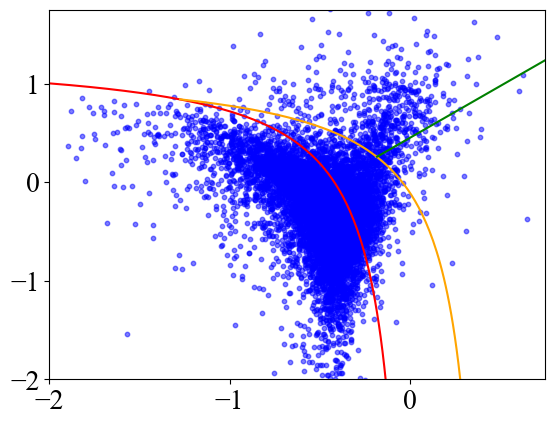

In [10]:
oiii_hbeta_ratio = dps_df['OIII5007_FLUX_1COMP'] / dps_df['Hbeta_FLUX_1COMP']
nii_halpha_ratio = dps_df['NII6583_FLUX_1COMP'] / dps_df['Halpha_FLUX_1COMP']
oiii_hbeta_ratio = dps_df['OIII5007_FLUX_2COMP_L'] / dps_df['Hbeta_FLUX_2COMP_L']
nii_halpha_ratio = dps_df['NII6583_FLUX_2COMP_L'] / dps_df['Halpha_FLUX_2COMP_L']
plt.scatter(np.log10(nii_halpha_ratio), np.log10(oiii_hbeta_ratio), c='blue', alpha=0.5, s=10)
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 1.75))
plt.show()

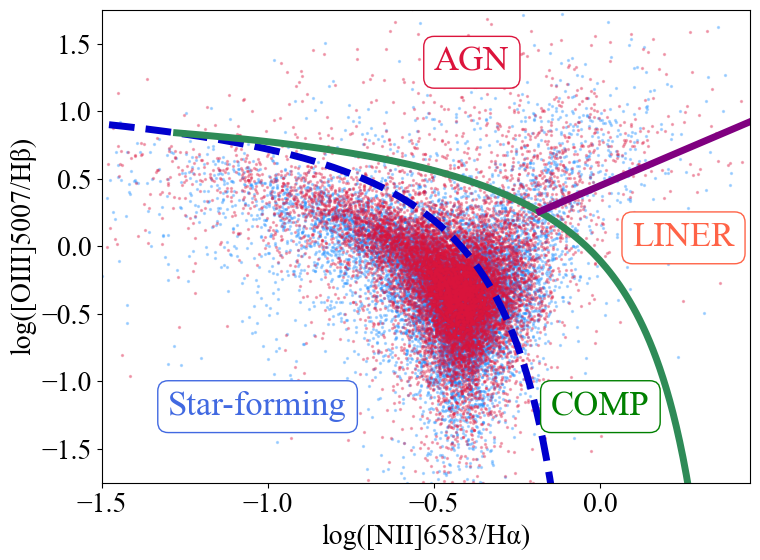

In [11]:
plt.figure(figsize=(8, 6))
# oiii_hbeta_ratio = dps_df['OIII5007_FLUX_1COMP'] / dps_df['Hbeta_FLUX_1COMP']
# nii_halpha_ratio = dps_df['NII6583_FLUX_1COMP'] / dps_df['Halpha_FLUX_1COMP']
oiii_hbeta_ratio = dps_df['OIII5007_FLUX_2COMP_L'] / dps_df['Hbeta_FLUX_2COMP_L']
nii_halpha_ratio = dps_df['NII6583_FLUX_2COMP_L'] / dps_df['Halpha_FLUX_2COMP_L']
plt.scatter(np.log10(nii_halpha_ratio), np.log10(oiii_hbeta_ratio), c='dodgerblue', alpha=0.3, s=2, label='Blue Comp', rasterized=True)

oiii_hbeta_ratio = dps_df['OIII5007_FLUX_2COMP_R'] / dps_df['Hbeta_FLUX_2COMP_R']
nii_halpha_ratio = dps_df['NII6583_FLUX_2COMP_R'] / dps_df['Halpha_FLUX_2COMP_R']
plt.scatter(np.log10(nii_halpha_ratio), np.log10(oiii_hbeta_ratio), c='crimson', alpha=0.3, s=2, label='Red Comp', rasterized=True)
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='mediumblue', linewidth=5, linestyle='--')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='seagreen', linewidth=5)
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='purple', linewidth=5)

plt.text(-1.3, -1.25, 'Star-forming', fontsize=25, ha='left', bbox=dict(boxstyle='round,pad=0.3', edgecolor='royalblue', facecolor='white'), color='royalblue')
plt.text(0.0, -1.25, 'COMP', fontsize=25, ha='center', bbox=dict(boxstyle='round,pad=0.3', edgecolor='green', facecolor='white'), color='green')
plt.text(-0.5, 1.3, 'AGN', fontsize=25, ha='left', bbox=dict(boxstyle='round,pad=0.3', edgecolor='crimson', facecolor='white'), color='crimson')
plt.text(0.25, 0.0, 'LINER', fontsize=25, ha='center', bbox=dict(boxstyle='round,pad=0.3', edgecolor='tomato', facecolor='white'), color='tomato')

plt.xlim((-1.5, 0.45))
plt.ylim((-1.75, 1.75))
plt.xlabel(r'log([NII]6583/Hα)')
plt.ylabel(r'log([OIII]5007/Hβ)')

# plt.legend(loc='upper left', fontsize=15)
plt.tight_layout()
plt.savefig('./figures/asroc/bpt_diagram.pdf', transparent=True, bbox_inches='tight')
plt.show()

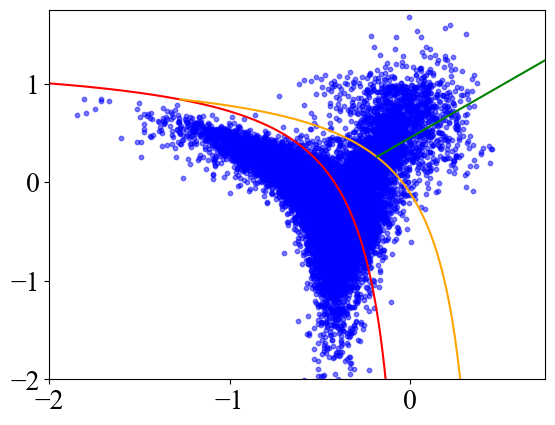

In [12]:
oiii_hbeta_ratio = all_df['OIII5007_FLUX_1COMP'] / all_df['Hbeta_FLUX_1COMP']
nii_halpha_ratio = all_df['NII6583_FLUX_1COMP'] / all_df['Halpha_FLUX_1COMP']
plt.scatter(np.log10(nii_halpha_ratio), np.log10(oiii_hbeta_ratio), c='blue', alpha=0.5, s=10)
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 1.75))
plt.show()

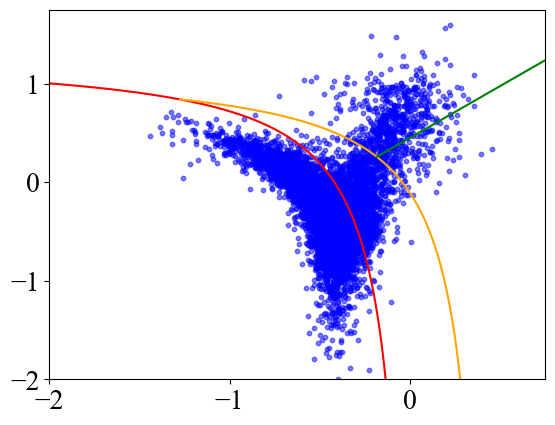

In [13]:
oiii_hbeta_ratio = nbcs_df['OIII5007_FLUX_1COMP'] / nbcs_df['Hbeta_FLUX_1COMP']
nii_halpha_ratio = nbcs_df['NII6583_FLUX_1COMP'] / nbcs_df['Halpha_FLUX_1COMP']
plt.scatter(np.log10(nii_halpha_ratio), np.log10(oiii_hbeta_ratio), c='blue', alpha=0.5, s=10)
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 1.75))
plt.show()